# MOD510: Project 3

**Deadline: 04. November 2025 (23:59)**


**Group members**

* Simen Sæverud Gåsland

* Nataliia Aksamentova

# Abstract 
**Write here**

# Introduction
**Write here**

# Exercise 1 : ...

**Intro here**

In [99]:
import numpy as np
import math

def func():
    '''
    dr/dt = f(r,t) , r and f are vectors
    r = (x, y, ...)
    f(r,t) = (fx(r,t), fy(r,t))
    '''
    pass

class ode_solver:
    '''
    Class docstring
    '''
    def __init__(self, f, t0, tf, h, r0):
        self.f = f
        self.t0 = t0
        self.tf = tf
        self.h = h
        self.n = math.ceil((tf - t0) / h)
        self.tpoints = np.linspace(t0, tf, self.n)
        self.r0 = np.array(r0, float)

    def eulers(self):
        '''
        Eulers method
        '''
        points = []
        r = self.r0.copy()
        for i, t in enumerate(self.tpoints):
            points.append(r.copy())
            r += self.h * self.f(r, t)
        return self.tpoints, np.array(points)

    def rk2(self):
        '''
        Runge-Kutta second order (RK2)
        '''
        points = []
        r = self.r0.copy()
        for i, t in enumerate(self.tpoints):
            points.append(r.copy())
            k1 = self.h * self.f(r, t)
            k2 = self.h * self.f(r + 0.5 * k1, t + 0.5 * self.h)
            r += k2
        return self.tpoints, np.array(points)

    def rk4(self):
        '''
        Runge-Kutta fourth order (RK4)
        '''
        points = []
        r = self.r0.copy()

        for i, t in enumerate(self.tpoints):
            points.append(r.copy())
            k1 = self.h * self.f(r, t)
            k2 = self.h * self.f(r + 0.5 * k1, t + 0.5 * self.h)
            k3 = self.h * self.f(r + 0.5 * k2, t + 0.5 * self.h)
            k4 = self.h * self.f(r + k3, t + self.h)
            r += (k1 + 2 * (k2 + k3) + k4) / 6
        return self.tpoints, np.array(points)

    def solve(self):
        '''
        Doc string for solve function
        '''

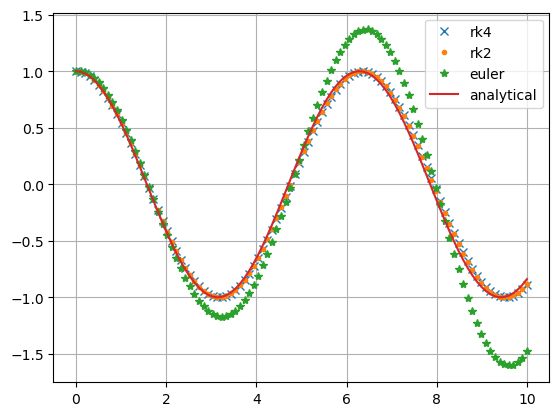

In [107]:
import matplotlib.pyplot as plt

def f(r,t):
    x, y = r
    fx = y
    fy = -x
    return np.array([fx, fy], float)

x0, y0 = 1.0, 0.0

cake = ode_solver(f, 0, 10, 0.1, [x0, y0])
t, sol = cake.rk4()
_, sol2 = cake.rk2()
_, sol3 = cake.eulers()

# Analytical expressions
x_analytical = x0 * np.cos(t) + y0 * np.sin(t)
y_analytical = -x0 * np.sin(t) + y0 * np.cos(t)


plt.plot(t, sol[:, 0], 'x',label = "rk4")
plt.plot(t, sol2[:, 0],'.', label = "rk2")
plt.plot(t, sol3[:, 0],'*', label = "euler")
plt.plot(t, x_analytical, '-', label = "analytical")
#plt.plot(t, y_analytical, '+', label = "analytical")
plt.legend()
plt.grid()

